##Customer Segmentation using Machine Learning

**Name:** Shubh Routh

**Topic:** Customer Segmentation

**Dataset:** [E-Commerce Customer Data](https://www.kaggle.com/code/fabiendaniel/customer-segmentation/input)

**Objective**

The objective of this project is to analyze customer transaction data and identify different groups of customers based on their purchasing behaviour. Customer segmentation helps businesses understand their customers better and supports targeted marketing strategies. In this project, the K-Means clustering algorithm is used to divide customers into meaningful segments using RFM (Recency, Frequency, and Monetary) analysis.

##Import Libraries

The first step of this project is importing the required Python libraries. These libraries help perform data analysis, create visualizations, preprocess the data, and build the machine learning model. Each library has a specific purpose that supports different stages of the customer segmentation process.


In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load the Dataset

Next, the E-Commerce customer transaction dataset is loaded into a Pandas DataFrame. The dataset contains customer purchase records, including invoice details, product information, quantity purchased, unit price, customer ID, and country. Loading the dataset allows the available information to be explored before further analysis.

In [34]:
df = pd.read_csv("data (2).csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Inspection

Before building the machine learning model, it is important to understand the dataset. The first few records, dataset dimensions, column names, data types, and summary statistics are examined to understand the structure of the data and identify any potential issues.

The following code provides an overview of the dataset before further preprocessing.

In [35]:
df.shape

(541909, 8)

In [36]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [38]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

After understanding the dataset, the next step is improving its quality. Missing values and duplicate records are identified and removed to ensure accurate analysis. Records without a Customer ID are excluded because customer segmentation requires information for each individual customer.

The following code checks the dataset for missing values and duplicate records before removing unnecessary entries.

In [39]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [40]:
df.duplicated().sum()

np.int64(5268)

In [41]:
df = df.drop_duplicates()

In [42]:
df = df.dropna(subset=["CustomerID"])

In [43]:
df.shape

(401604, 8)

## Exploratory Data Analysis

The following analysis explores customer purchasing behaviour using visualizations. These graphs help identify patterns in transaction quantities, product prices, and customer distribution across different countries before applying machine learning techniques.

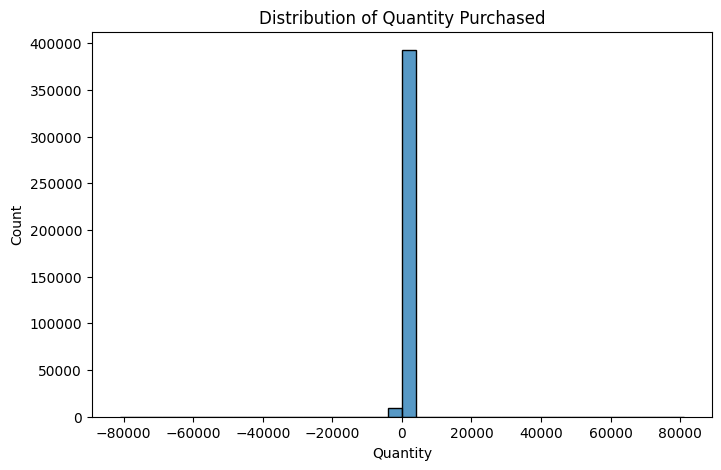

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"], bins=40)
plt.title("Distribution of Quantity Purchased")
plt.show()

**Observation**

Most transactions involve purchasing relatively small quantities of products, while only a few transactions contain very large purchase quantities. This indicates that the data is positively skewed with some extreme values.

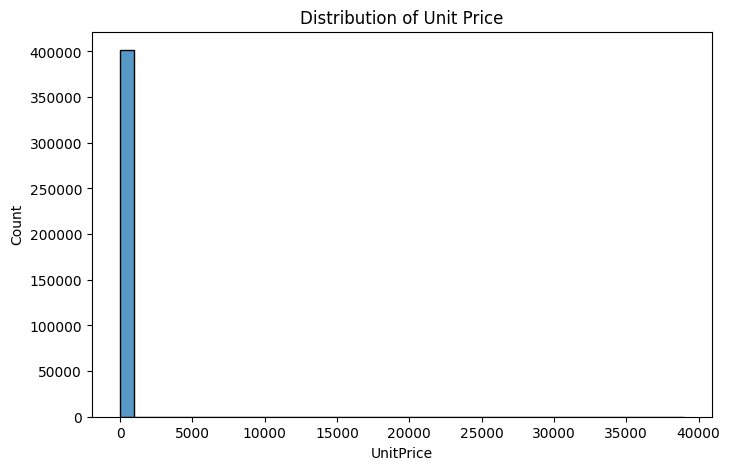

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df["UnitPrice"], bins=40)
plt.title("Distribution of Unit Price")
plt.show()

**Observation**

The majority of products have relatively low prices, while only a small number of products are sold at much higher prices. This suggests that most customer purchases occur within a lower price range.

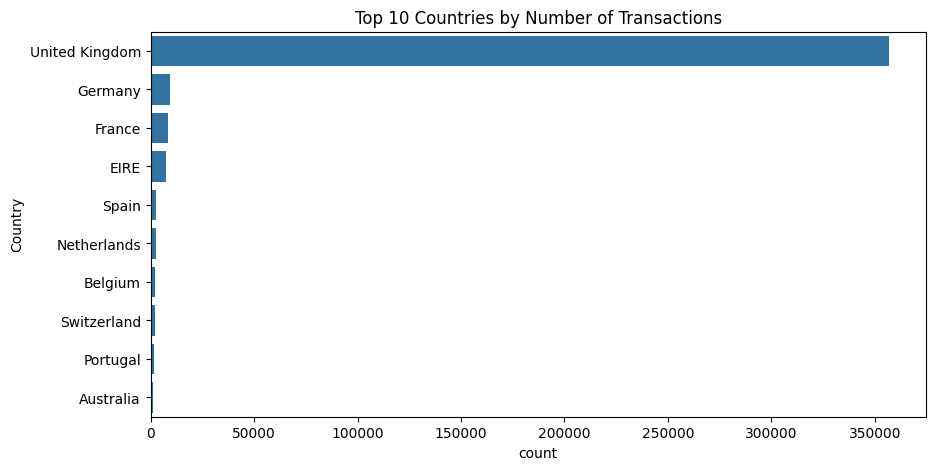

In [46]:
plt.figure(figsize=(10,5))
sns.countplot(y=df["Country"], order=df["Country"].value_counts().head(10).index)
plt.title("Top 10 Countries by Number of Transactions")
plt.show()

**Observation**

The United Kingdom accounts for the highest number of customer transactions in the dataset. Other countries contribute significantly fewer transactions, indicating that the business primarily serves customers from the United Kingdom.

In [47]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Feature Engineering (RFM Analysis)

To better represent customer purchasing behaviour, new RFM features are created from the transaction data. Recency measures how recently a customer made a purchase, Frequency measures how often purchases were made, and Monetary represents the total amount spent by each customer.

The code below creates the RFM features that will be used for customer segmentation.

In [49]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [50]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [51]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

In [52]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [53]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


**Observation**

The RFM table summarizes each customer's purchasing behaviour into three numerical features. Instead of analyzing individual transactions, each customer is now represented by Recency, Frequency, and Monetary values, making the dataset suitable for clustering.

## Data Preparation

Before training the clustering model, the RFM features are standardized using StandardScaler. Standardization ensures that each feature contributes equally during clustering by transforming the values onto a similar scale.

The following code standardizes the RFM values before they are used for clustering.

In [54]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)


In [55]:
rfm_scaled

array([[ 2.32202285, -0.32936215, -0.23041952],
       [-0.89373323,  0.20610242,  0.29405454],
       [-0.1691956 , -0.11517632, -0.01171748],
       ...,
       [-0.83418219, -0.22226923, -0.20892947],
       [-0.87388289,  1.16993863,  0.01849636],
       [-0.48680114, -0.22226923, -0.00684511]])

## Finding the Optimal Number of Clusters

Before applying the K-Means algorithm, it is necessary to determine a suitable number of customer clusters. The Elbow Method calculates the Within-Cluster Sum of Squares (WCSS) for different values of K to identify the most appropriate number of clusters.

The following code calculates the WCSS values and plots the Elbow Method graph.

In [56]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

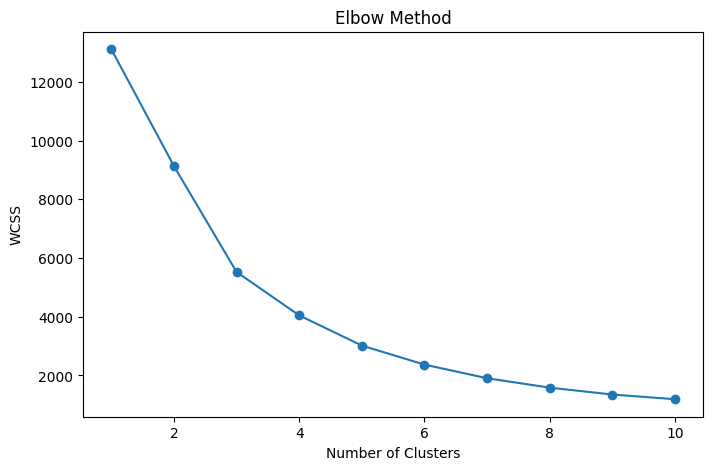

In [57]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

**Observation**

The Elbow Method graph shows a noticeable bend around five clusters. Therefore, five clusters were selected as the optimal number for customer segmentation using the K-Means algorithm.

## Model Building

Once the optimal number of clusters has been identified, the K-Means clustering algorithm is applied to group customers with similar purchasing behaviour. Since customer segmentation is an unsupervised learning problem, the algorithm automatically identifies patterns without predefined labels.

The following code trains the K-Means model and assigns each customer to a cluster.

In [58]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [59]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


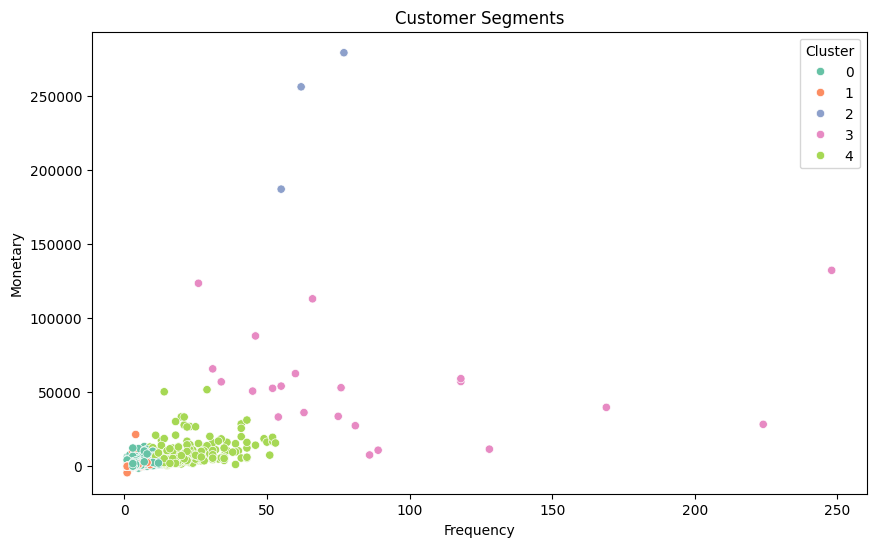

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

**Observation**

The scatter plot shows that customers are divided into different groups based on their purchasing behaviour. Some customers purchase more frequently and spend higher amounts, while others purchase less often and spend less. These differences demonstrate the effectiveness of customer segmentation.

## Cluster Summary

Finally, the average Recency, Frequency, and Monetary values are calculated for each customer segment. This summary helps interpret the characteristics of every cluster and provides meaningful business insights.

The results below summarize the characteristics of each customer cluster.

In [61]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,44.189381,3.887048,1177.034107
1,249.507003,1.802988,452.053512
2,3.666667,64.666667,241083.226667
3,6.181818,88.363636,54563.856364
4,13.771160,20.774295,7492.870658


## Business Insights

- Customers in different clusters exhibit different purchasing behaviours.
- Some customer groups purchase more frequently and spend higher amounts than others.
- Businesses can use these customer segments to create personalized marketing campaigns and improve customer retention.
- High-value customers can be rewarded through loyalty programs, while less active customers can be targeted with promotional offers to encourage future purchases.

# Conclusion

In this project, customer transaction data was analyzed using the K-Means clustering algorithm to identify different customer segments. The dataset was inspected, cleaned, and transformed using RFM (Recency, Frequency, and Monetary) analysis. The features were standardized before applying the clustering model.

The Elbow Method was used to determine an appropriate number of clusters, and customers were grouped into five meaningful segments based on their purchasing behaviour. The results demonstrate that different customer groups have different shopping patterns, spending habits, and purchase frequencies.

Overall, customer segmentation provides valuable business insights that can help organizations improve marketing strategies, enhance customer retention, and make better data-driven business decisions.